In [1]:
import os
import sys
import pandas as pd

In [2]:
csv_filename = '../data/results.csv'
df = pd.read_csv(csv_filename)
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
sys.path.append(os.path.abspath('..'))
from src.elo_system import calculate_elo_ratings
from src.features import add_form_features, add_h2h_feature, add_tournament_type

In [4]:
df = add_tournament_type(df)

In [5]:
df.loc[49307, 'date'] = '2026-06-04'  # was testing the incorrect dated match's effect on features like elo
print(df.loc[49307]) 
df = calculate_elo_ratings(df)
df = add_form_features(df)
df = add_h2h_feature(df)
df.tail()

date                                                      2026-06-04
home_team                                                   Maldives
away_team                                                   Pakistan
home_score                                                       0.0
away_score                                                       3.0
tournament         Diamond Jubilee International Football Tournament
city                                                            Malé
country                                                     Maldives
neutral                                                        False
tournament_type                                 Other / Regional Cup
Name: 49307, dtype: object


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,tournament_type,...,elo_diff,home_average_goals_scored,home_average_conceded_goals,home_elo_momentum,away_average_goals_scored,away_average_conceded_goals,away_elo_momentum,conceded_goals_diff,scored_goals_diff,h2h_win_pct
49500,2026-07-07,Switzerland,Colombia,0.0,0.0,FIFA World Cup,Vancouver,Canada,True,Major Tournament,...,-74.092344,2.2,1.1,23.490595,1.7,0.8,23.776135,0.3,0.5,0.375000
49501,2026-07-09,France,Morocco,NaN,NaN,FIFA World Cup,Foxborough,United States,True,Major Tournament,...,140.897190,2.6,0.8,83.264078,2.3,0.7,59.317872,0.1,0.3,0.833333
49502,2026-07-10,Spain,Belgium,NaN,NaN,FIFA World Cup,Inglewood,United States,True,Major Tournament,...,209.560904,1.8,0.4,-14.375131,3.3,0.8,51.661754,-0.4,-1.5,0.900000
49503,2026-07-11,Norway,England,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,Major Tournament,...,-132.342304,2.1,1.4,89.122902,1.8,0.7,34.172887,0.7,0.3,0.350000
49504,2026-07-11,Argentina,Switzerland,NaN,NaN,FIFA World Cup,Kansas City,United States,True,Major Tournament,...,208.818004,2.8,0.6,41.089762,1.8,1.0,61.596206,-0.4,1.0,0.857143


nice

--- Mutual Information Scores ---
elo_diff                       0.101930
h2h_win_pct                    0.054697
conceded_goals_diff            0.053833
away_elo                       0.038118
scored_goals_diff              0.033157
away_average_conceded_goals    0.026278
home_elo                       0.019241
home_average_goals_scored      0.012821
away_average_goals_scored      0.012684
home_average_conceded_goals    0.010946
dtype: float64


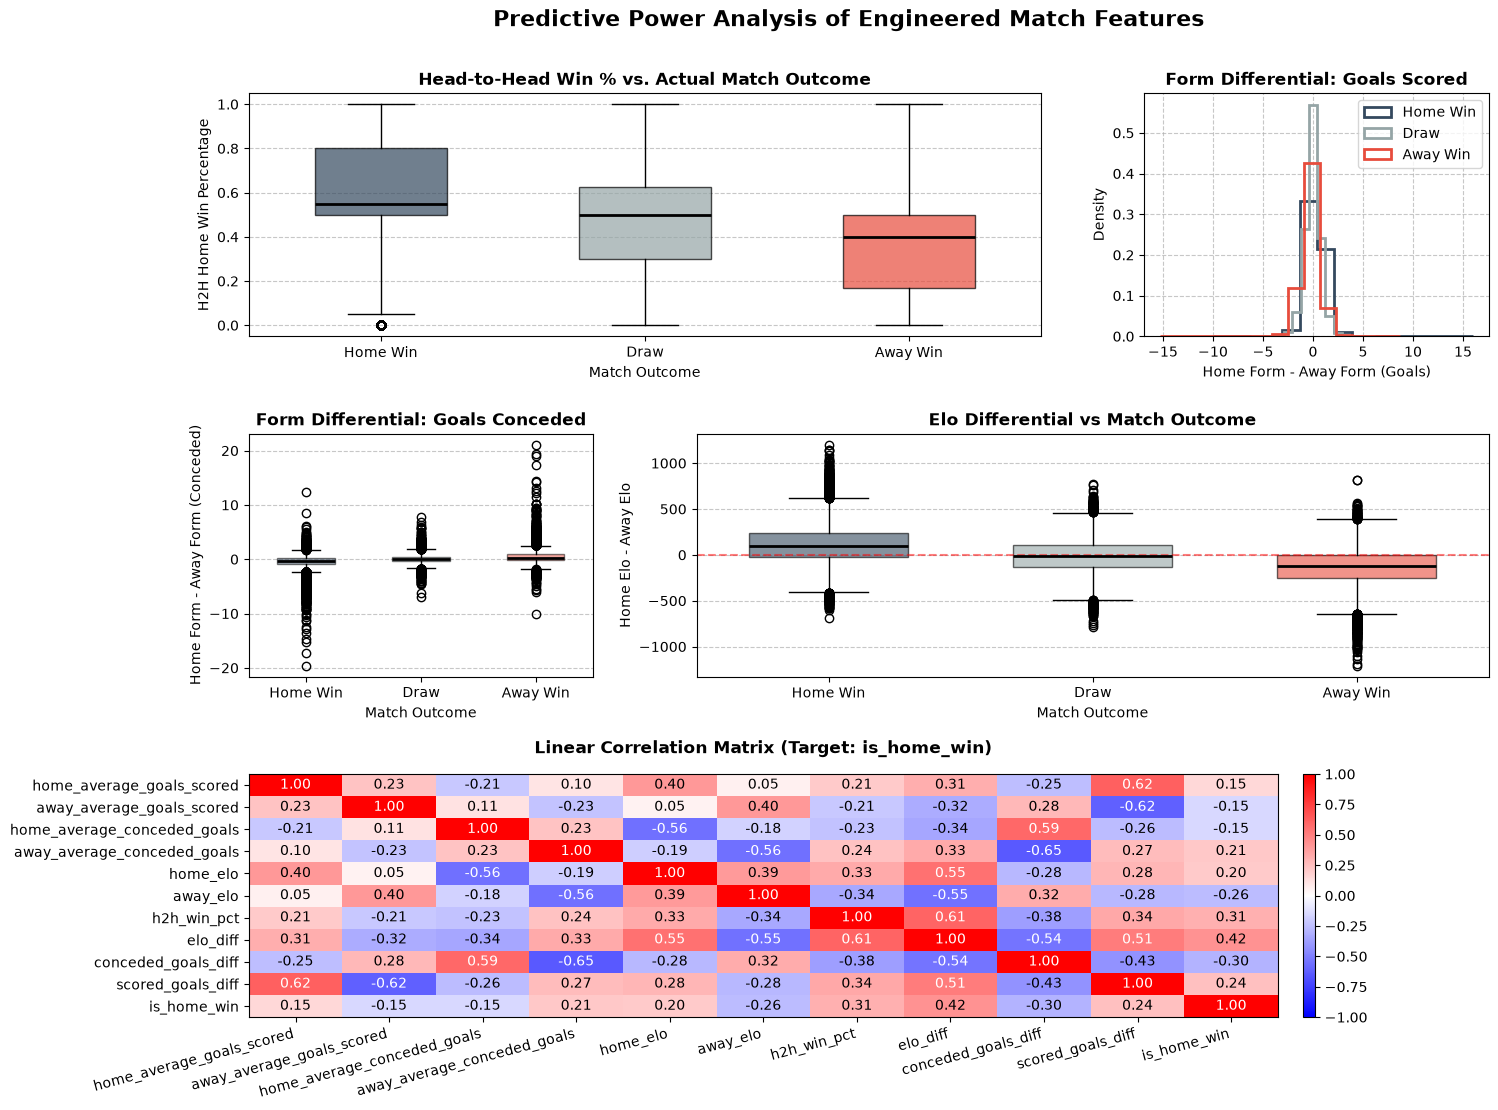

In [6]:
from sklearn.feature_selection import mutual_info_classif
import numpy as np
import matplotlib.pyplot as plt

def plot_feature_impact(df):
    """
    Plots the distribution and impact of form and H2H features
    against the actual match outcomes using pure matplotlib.
    """
    # 1. Create a clean copy and define the target match outcome
    plot_df = df.copy()
    
    conditions = [
        (plot_df['home_score'] > plot_df['away_score']),
        (plot_df['home_score'] == plot_df['away_score']),
        (plot_df['home_score'] < plot_df['away_score'])
    ]
    choices = ['Home Win', 'Draw', 'Away Win']
    plot_df['match_outcome'] = np.select(conditions, choices, default='Draw')
    
    # Drop rows where rolling stats haven't accumulated yet (NaNs)
    features = [
        'home_average_goals_scored', 'away_average_goals_scored',
        'home_average_conceded_goals', 'away_average_conceded_goals',
        'home_elo', 'away_elo', 'h2h_win_pct', 'elo_diff', 'conceded_goals_diff',
        'scored_goals_diff'
    ]
    plot_df = plot_df.dropna(subset=features).reset_index(drop=True)
    
    # Group data by outcome for localized plotting arrays
    outcomes = ['Home Win', 'Draw', 'Away Win']
    grouped_data = {outcome: plot_df[plot_df['match_outcome'] == outcome] for outcome in outcomes}
    
    colors_dict = {'Home Win': '#34495e', 'Draw': '#95a5a6', 'Away Win': '#e74c3c'}
    
    # 2. Setup a multi-panel visualization figure
    fig = plt.figure(figsize=(16, 12), facecolor='white')
    gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)
    
    # --- VISUALIZATION 1: H2H Win Percentage Boxplot ---
    ax1 = fig.add_subplot(gs[0, 0:2])
    h2h_data = [grouped_data[o]['h2h_win_pct'].values for o in outcomes]
    # FIX: Changed 'labels' to 'tick_labels' for Matplotlib 3.9+ compatibility
    bplot1 = ax1.boxplot(h2h_data, tick_labels=outcomes, patch_artist=True, widths=0.5)
    
    # Apply flat styling colors
    for patch, outcome in zip(bplot1['boxes'], outcomes):
        patch.set_facecolor(colors_dict[outcome])
        patch.set_alpha(0.7)
    for median in bplot1['medians']:
        median.set(color='black', linewidth=2)
        
    ax1.set_title('Head-to-Head Win % vs. Actual Match Outcome', weight='bold')
    ax1.set_xlabel('Match Outcome')
    ax1.set_ylabel('H2H Home Win Percentage')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    # --- VISUALIZATION 2: Goal Scoring Differences ---
    plot_df['goal_scoring_diff'] = plot_df['home_average_goals_scored'] - plot_df['away_average_goals_scored']
    ax2 = fig.add_subplot(gs[0, 2])
    
    for outcome in outcomes:
        sub_data = grouped_data[outcome]['home_average_goals_scored'] - grouped_data[outcome]['away_average_goals_scored']
        if not sub_data.empty:
            ax2.hist(sub_data, bins=15, histtype='step', linewidth=2, 
                     color=colors_dict[outcome], label=outcome, density=True)
            
    ax2.set_title('Form Differential: Goals Scored', weight='bold')
    ax2.set_xlabel('Home Form - Away Form (Goals)')
    ax2.set_ylabel('Density')
    ax2.legend()
    ax2.grid(linestyle='--', alpha=0.7)
    
    # --- VISUALIZATION 3: Goals Conceded Differences Boxplot ---
    plot_df['goal_conceded_diff'] = plot_df['home_average_conceded_goals'] - plot_df['away_average_conceded_goals']
    ax3 = fig.add_subplot(gs[1, 0])
    
    conceded_data = [
        (grouped_data[o]['home_average_conceded_goals'] - grouped_data[o]['away_average_conceded_goals']).values 
        for o in outcomes
    ]
    # FIX: Changed 'labels' to 'tick_labels'
    bplot3 = ax3.boxplot(conceded_data, tick_labels=outcomes, patch_artist=True, widths=0.5)
    
    for patch, outcome in zip(bplot3['boxes'], outcomes):
        patch.set_facecolor(colors_dict[outcome])
        patch.set_alpha(0.5)
    for median in bplot3['medians']:
        median.set(color='black', linewidth=2)
        
    ax3.set_title('Form Differential: Goals Conceded', weight='bold')
    ax3.set_xlabel('Match Outcome')
    ax3.set_ylabel('Home Form - Away Form (Conceded)')
    ax3.grid(axis='y', linestyle='--', alpha=0.7)
    
    # --- VISUALIZATION 4: ELO Differential vs Outcome ---
    ax4 = fig.add_subplot(gs[1, 1:3])
    
    elo_data = [
        (grouped_data[o]['home_elo'] - grouped_data[o]['away_elo']).values 
        for o in outcomes
    ]
    # FIX: Changed 'labels' to 'tick_labels'
    bplot4 = ax4.boxplot(elo_data, tick_labels=outcomes, patch_artist=True, widths=0.6)
    
    for patch, outcome in zip(bplot4['boxes'], outcomes):
        patch.set_facecolor(colors_dict[outcome])
        patch.set_alpha(0.6)
    for median in bplot4['medians']:
        median.set(color='black', linewidth=2)
        
    ax4.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax4.set_title('Elo Differential vs Match Outcome', weight='bold')
    ax4.set_xlabel('Match Outcome')
    ax4.set_ylabel('Home Elo - Away Elo')
    ax4.grid(axis='y', linestyle='--', alpha=0.7)

    # --- VISUALIZATION 5: Feature Correlation Matrix Heatmap ---
    plot_df['is_home_win'] = (plot_df['match_outcome'] == 'Home Win').astype(int)
    corr_cols = features + ['is_home_win']
    corr_matrix = plot_df[corr_cols].corr().values
    
    ax5 = fig.add_subplot(gs[2, 0:3])
    cax = ax5.imshow(corr_matrix, cmap='bwr', vmin=-1, vmax=1, aspect='auto')
    
    for i in range(len(corr_cols)):
        for j in range(len(corr_cols)):
            ax5.text(j, i, f"{corr_matrix[i, j]:.2f}", 
                     ha="center", va="center", 
                     color="black" if abs(corr_matrix[i, j]) < 0.5 else "white")
            
    ax5.set_xticks(np.arange(len(corr_cols)))
    ax5.set_yticks(np.arange(len(corr_cols)))
    ax5.set_xticklabels(corr_cols, rotation=15, ha='right')
    ax5.set_yticklabels(corr_cols)
    
    fig.colorbar(cax, ax=ax5, orientation='vertical', pad=0.02)
    ax5.set_title('Linear Correlation Matrix (Target: is_home_win)', weight='bold', pad=15)
    ax5.grid(False)


      # 1. Calculate the scores
    mi_scores = mutual_info_classif(plot_df[features], plot_df['is_home_win'])
    
    # 2. Map names to scores and sort them
    mi_series = pd.Series(mi_scores, index=features).sort_values(ascending=False)
    
    # 3. Print the scannable results
    print("--- Mutual Information Scores ---")
    print(mi_series)
    
    plt.suptitle('Predictive Power Analysis of Engineered Match Features', fontsize=16, weight='bold', y=0.95)
    plt.show()

# --- EXECUTION ---
plot_feature_impact(df)

Elo diff is the strongest feature by far followed by h2h win pct and away teams elo.       
Its intuitive why these are the stronger indicators from the engineered features.    
They also share information with one another so there may be some redundancy.   
Something to note is that away's elo has more mutual information with is_home_win than home's elo.   
This could be because the quality of the travelling team matters more when non-neutral ground and 70%+ games are on non-neutral ground.    
Another interesting thing to think about is how the other features will influence the outcome when elo difference is low.    

The difference in goals conceded in last 5 games also seems like a promising indicator and isn't directly related to the two teams history and elo.   
The difference in goals scored is also a promising indicator although less than goals conceded potentially leaning towards stronger defending teams having an advantage.